# Online Matching: Nearest-Neighbour, Caliper, and Kernel

Matching creates counterfactual comparisons by pairing each treated unit with the most similar control unit (and vice-versa). OnlineCML implements a **sliding-window nearest-neighbour** (SWINN) approach that works in a streaming setting.

| Method | How it matches | Notes |
|---|---|---|
| `OnlineMatching` | k-NN in covariate space | Euclidean distance |
| `OnlineCaliperMatching` | k-NN with max-distance guard | Drops unmatched units |
| `OnlineKernelMatching` | Gaussian-kernel weighted average | Smooth, uses all buffer units |

**Distance functions:** `euclidean_distance`, `ps_distance`, `mahalanobis_distance`, `combined_distance`.

In [1]:
from onlinecml.datasets import LinearCausalStream
from onlinecml.matching import OnlineMatching, OnlineCaliperMatching, OnlineKernelMatching
from onlinecml.matching.distance import euclidean_distance, ps_distance, combined_distance

## 1. Distance function examples

In [2]:
x1 = {"age": 30.0, "income": 50_000.0}
x2 = {"age": 35.0, "income": 60_000.0}

print(f"Euclidean distance : {euclidean_distance(x1, x2):.2f}")
print(f"PS distance (0.3 vs 0.7) : {ps_distance(0.3, 0.7):.2f}")
print(f"Combined (ps_weight=0.5) : {combined_distance(x1, x2, 0.3, 0.7, ps_weight=0.5):.2f}")

Euclidean distance : 10000.00
PS distance (0.3 vs 0.7) : 0.40
Combined (ps_weight=0.5) : 5000.20


## 2. Fit all three matching methods

In [3]:
N = 500
TRUE_ATE = 2.0

nn  = OnlineMatching(k=3, buffer_size=200)
cal = OnlineCaliperMatching(caliper=2.0, buffer_size=200)
ker = OnlineKernelMatching(bandwidth=1.5, buffer_size=200)

for x, w, y, _ in LinearCausalStream(n=N, true_ate=TRUE_ATE, seed=42):
    nn.learn_one(x, w, y)
    cal.learn_one(x, w, y)
    ker.learn_one(x, w, y)

print(f"True ATE            : {TRUE_ATE:.3f}")
print(f"NN Matching ATE     : {nn.predict_ate():.3f}  (n_seen={nn.n_seen})")
print(f"Caliper Matching ATE: {cal.predict_ate():.3f}  (common_support={cal.common_support_rate:.2%})")
print(f"Kernel Matching ATE : {ker.predict_ate():.3f}  (n_seen={ker.n_seen})")

True ATE            : 2.000
NN Matching ATE     : 2.310  (n_seen=500)
Caliper Matching ATE: 2.147  (common_support=93.80%)
Kernel Matching ATE : 2.579  (n_seen=500)


## 3. Effect of caliper on common support

Saved to /tmp/caliper_tradeoff.png


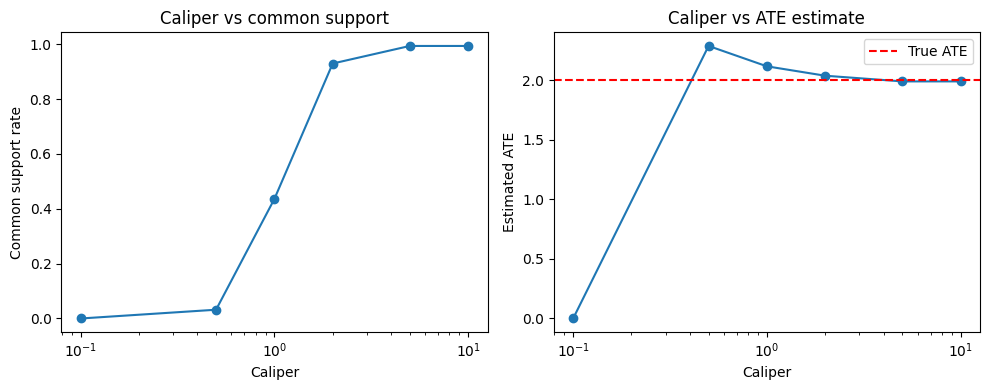

In [4]:
import matplotlib
import matplotlib.pyplot as plt

calipers = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
support_rates = []
ate_estimates = []

for c in calipers:
    m = OnlineCaliperMatching(caliper=c)
    for x, w, y, _ in LinearCausalStream(n=500, true_ate=2.0, seed=0):
        m.learn_one(x, w, y)
    support_rates.append(m.common_support_rate)
    ate_estimates.append(m.predict_ate())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(calipers, support_rates, marker="o")
ax1.set_xlabel("Caliper")
ax1.set_ylabel("Common support rate")
ax1.set_title("Caliper vs common support")
ax1.set_xscale("log")

ax2.plot(calipers, ate_estimates, marker="o")
ax2.axhline(2.0, color="red", linestyle="--", label="True ATE")
ax2.set_xlabel("Caliper")
ax2.set_ylabel("Estimated ATE")
ax2.set_title("Caliper vs ATE estimate")
ax2.set_xscale("log")
ax2.legend()

plt.tight_layout()
plt.savefig("/tmp/caliper_tradeoff.png", dpi=100)
print("Saved to /tmp/caliper_tradeoff.png")

## 4. Buffer size effect on NN matching

In [5]:
buffer_sizes = [10, 25, 50, 100, 200, 500]
nn_ates = []

for buf in buffer_sizes:
    m = OnlineMatching(k=3, buffer_size=buf)
    for x, w, y, _ in LinearCausalStream(n=500, true_ate=2.0, seed=5):
        m.learn_one(x, w, y)
    nn_ates.append(m.predict_ate())

print(f"{'Buffer':>8} | {'ATE':>8} | {'Error':>8}")
print("-" * 32)
for buf, ate in zip(buffer_sizes, nn_ates):
    print(f"{buf:>8} | {ate:>8.3f} | {abs(ate - 2.0):>8.3f}")

  Buffer |      ATE |    Error
--------------------------------
      10 |    2.620 |    0.620
      25 |    2.475 |    0.475
      50 |    2.385 |    0.385
     100 |    2.306 |    0.306
     200 |    2.280 |    0.280
     500 |    2.280 |    0.280
